# Détection de fraude électrique par analyse des données de consommation

**Projet réalisé lors d'un stage à Électricité de Djibouti (EDD), avril–août 2026.**

⚠️ **Note sur les données** : pour des raisons de confidentialité, ce dépôt utilise un
jeu de données **synthétique**, généré pour reproduire les propriétés statistiques du
jeu de données réel (mêmes catégories tarifaires, mêmes ordres de grandeur de
consommation, même structure de colonnes, comportements frauduleux simulés). Aucune
donnée client réelle d'EDD n'apparaît dans ce notebook. La méthodologie et le code
sont ceux effectivement utilisés dans le projet réel.

## Contexte

La fraude électrique constitue un enjeu majeur pour les fournisseurs d'énergie. En
l'absence de labels historiques de fraude exploitables, ce projet formule la détection
de fraude comme un problème d'**apprentissage non supervisé**, combinant trois
algorithmes complémentaires :

- **K-Means** : détection par distance au centroïde et micro-clusters
- **Isolation Forest** : détection par isolement algorithmique
- **Local Outlier Factor (LOF)** : détection par densité locale

Un **score composite** consolide les trois méthodes, avec un critère de consensus
inter-méthodes (détection par au moins 2 méthodes sur 3) pour prioriser les
investigations terrain.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 1. Chargement et audit des données

Le jeu de données (synthétique) simule 10 000 contrats clients sur la période
2024–2026, avec la même structure de colonnes que l'extraction SQL réelle
(voir requête en annexe du rapport de stage).

In [2]:
df = pd.read_csv("donnees_synthetiques_edd.csv")
df["date_releve"] = pd.to_datetime(df["date_releve"])
df["date_emission"] = pd.to_datetime(df["date_emission"])
df["nom_categorie"] = df["nom_categorie"].astype("category")

print(f"Lignes : {len(df)}")
print(f"Contrats uniques : {df['id_contrat'].nunique()}")
df.head()


Lignes : 135658
Contrats uniques : 10000


,id_contrat,id_periode,annee,mois_num,num_releve,date_releve,date_emission,index_a,conso_reelle,conso_moyenne,type_releve,nature_releve,num_facture,montant,puissance,nom_categorie,ecart_jours
0,100000,202404,2024,4,R100000-0,2024-04-27,2024-04-30,338219.7,1351.8,1359.9,REEL,PERIODIQUE,F100000-0,39112.0,3,GENERAL,60
1,100000,202406,2024,6,R100000-1,2024-06-24,2024-06-28,37785.5,942.0,1314.5,REEL,PERIODIQUE,F100000-1,27390.0,3,GENERAL,58
2,100000,202407,2024,7,R100000-2,2024-07-25,2024-07-28,238767.9,529.1,702.6,REEL,PERIODIQUE,F100000-2,17320.0,3,GENERAL,31
3,100000,202409,2024,9,R100000-3,2024-09-24,2024-09-28,388174.6,1162.4,1382.5,REEL,PERIODIQUE,F100000-3,38430.0,3,GENERAL,61
4,100000,202411,2024,11,R100000-4,2024-11-25,2024-11-26,38574.4,1629.7,1405.2,REEL,PERIODIQUE,F100000-4,52270.0,3,GENERAL,62


In [3]:
# Audit de cohérence : doublons, valeurs manquantes, valeurs négatives
print("Doublons stricts :", df.duplicated().sum())
print("Valeurs manquantes :", df.isnull().sum().sum())
print("Consommations négatives :", (df['conso_reelle'] < 0).sum())
print("Puissances nulles :", (df['puissance'] <= 0).sum())


Doublons stricts : 0
Valeurs manquantes : 0
Consommations négatives : 0
Puissances nulles : 0


## 2. Analyse exploratoire

### 2.1 Structure du portefeuille client

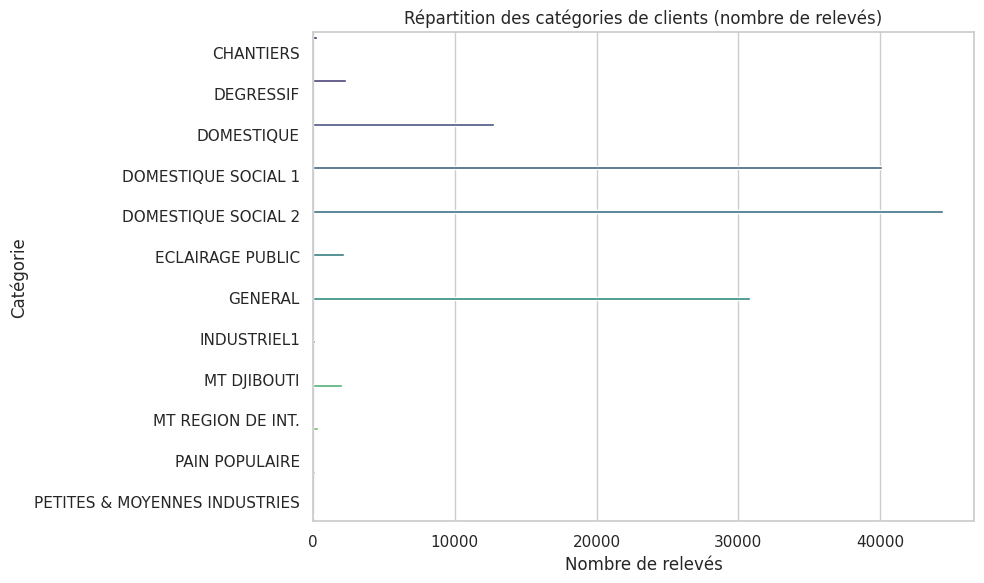

In [4]:
cat_counts = df['nom_categorie'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index,
            palette="viridis", legend=False)
plt.title("Répartition des catégories de clients (nombre de relevés)")
plt.xlabel("Nombre de relevés")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()


In [5]:
# Statistiques descriptives et asymétrie (skewness)
cols = ["conso_reelle", "conso_moyenne", "montant", "puissance"]
stats_table = df[cols].describe()
stats_table.loc["skewness"] = df[cols].skew()
stats_table


,conso_reelle,conso_moyenne,montant,puissance
count,1.356580e+05,135658.000000,1.356580e+05,135658.000000
mean,3.761041e+03,3547.206141,1.164080e+05,6.037712
std,2.175656e+04,19976.922644,6.739120e+05,7.910826
min,1.500000e+00,46.900000,4.600000e+01,1.000000
25%,3.251000e+02,335.000000,1.005100e+04,1.000000
50%,5.945000e+02,586.050000,1.841100e+04,3.000000
75%,1.306275e+03,1288.800000,4.047200e+04,6.000000
max,1.280157e+06,871594.400000,4.063014e+07,60.000000
skewness,1.426112e+01,12.098097,1.430790e+01,3.678145


### 2.2 Distribution de la consommation réelle

Comme dans le jeu de données réel, la distribution est fortement asymétrique à droite
(quelques très gros consommateurs tirent la queue de distribution).

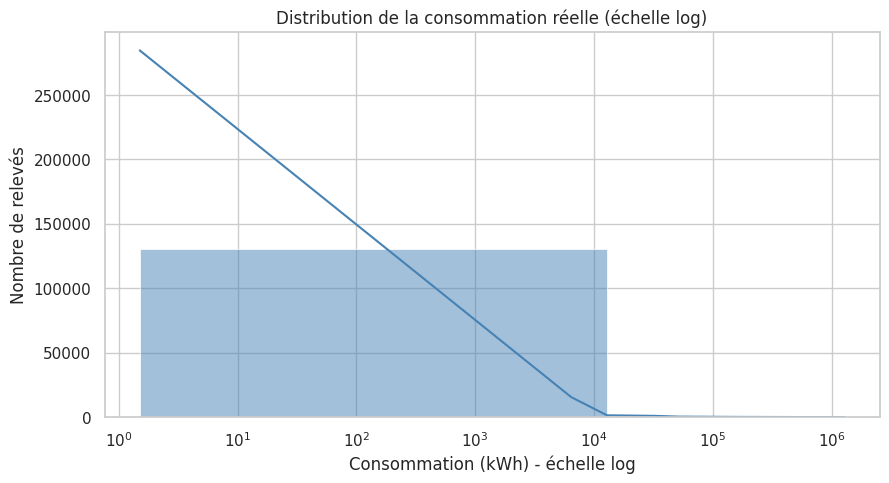

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['conso_reelle'], bins=100, kde=True, color="steelblue")
plt.xscale("log")
plt.title("Distribution de la consommation réelle (échelle log)")
plt.xlabel("Consommation (kWh) - échelle log")
plt.ylabel("Nombre de relevés")
plt.show()


### 2.3 Corrélations (Spearman)

Le coefficient de Spearman est préféré à Pearson car les distributions sont fortement
non gaussiennes (cf. skewness ci-dessus) — cf. rapport, section 3.6.1.

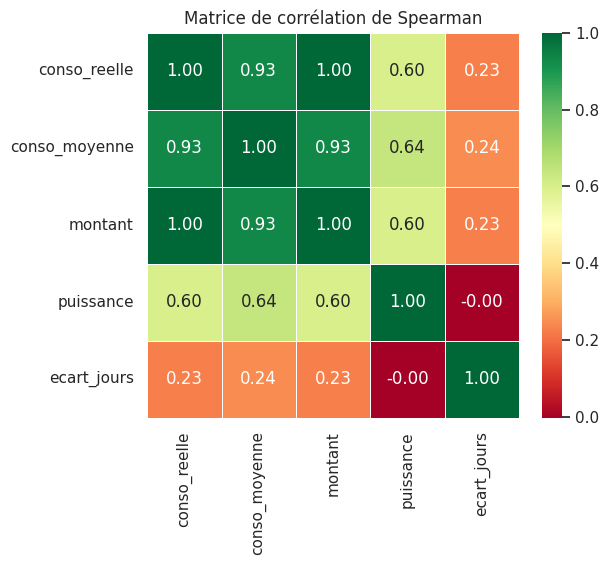

In [7]:
corr_cols = ["conso_reelle", "conso_moyenne", "montant", "puissance", "ecart_jours"]
corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation de Spearman")
plt.show()


## 3. Ingénierie des variables (feature engineering)

Quatre variables discriminantes sont construites pour capturer le comportement réel
des usagers, indépendamment de leur volume de consommation brut :

1. **Consommation journalière** (kWh/jour) — normalise par la durée de la période
2. **Ratio de cohérence technique** (kWh/j/kVA) — consommation rapportée à la puissance souscrite
3. **Coefficient de variation (cv)** — stabilité temporelle de la consommation du client
4. **Chute brutale** — variation relative entre deux cycles consécutifs


In [8]:
df = df.sort_values(["id_contrat", "date_releve"]).copy()

# 1. Consommation journalière
df["conso_journaliere"] = df["conso_reelle"] / df["ecart_jours"]

# 2. Ratio de cohérence technique
df["ratio_coherence"] = df["conso_journaliere"] / df["puissance"]

# 3. Coefficient de variation (par client)
df["cv"] = df.groupby("id_contrat", observed=True)["conso_journaliere"] \
             .transform(lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan)

# 4. Chute brutale (variation relative entre cycles consécutifs)
df["chute_brutale"] = df.groupby("id_contrat", observed=True)["conso_journaliere"] \
                         .pct_change()

df[["id_contrat", "conso_journaliere", "ratio_coherence", "cv", "chute_brutale"]].head(10)


,id_contrat,conso_journaliere,ratio_coherence,cv,chute_brutale
0,100000,22.530000,7.510000,0.31689,NaN
1,100000,16.241379,5.413793,0.31689,-0.279122
2,100000,17.067742,5.689247,0.31689,0.050880
3,100000,19.055738,6.351913,0.31689,0.116477
4,100000,26.285484,8.761828,0.31689,0.379400
5,100000,27.688710,9.229570,0.31689,0.053384
6,100000,33.226667,11.075556,0.31689,0.200008
7,100000,14.660345,4.886782,0.31689,-0.558778
8,100000,29.539655,9.846552,0.31689,1.014936
9,100000,37.482759,12.494253,0.31689,0.268896


## 4. Détection exploratoire par la méthode IQR

Première détection rapide, appliquée indépendamment par catégorie tarifaire (respect
de l'hétérogénéité du portefeuille), avant les méthodes multivariées.

In [9]:
def suspects_iqr(groupe, colonne="conso_journaliere"):
    q1 = groupe[colonne].quantile(0.25)
    q3 = groupe[colonne].quantile(0.75)
    seuil = q3 + 1.5 * (q3 - q1)
    return groupe[groupe[colonne] > seuil], seuil

resultats_iqr = []
for cat in df["nom_categorie"].cat.categories:
    sous_groupe = df[df["nom_categorie"] == cat]
    if len(sous_groupe) == 0:
        continue
    suspects, seuil = suspects_iqr(sous_groupe)
    resultats_iqr.append({
        "categorie": cat,
        "n_relevés": len(sous_groupe),
        "seuil_kwh_j": round(seuil, 2),
        "n_suspects": len(suspects),
        "taux_pct": round(100 * len(suspects) / len(sous_groupe), 2),
    })

pd.DataFrame(resultats_iqr).sort_values("n_relevés", ascending=False)


,categorie,n_relevés,seuil_kwh_j,n_suspects,taux_pct
4,DOMESTIQUE SOCIAL 2,44407,20.21,1626,3.66
3,DOMESTIQUE SOCIAL 1,40155,11.03,1454,3.62
6,GENERAL,30847,62.51,1172,3.80
2,DOMESTIQUE,12741,44.33,465,3.65
1,DEGRESSIF,2351,1089.53,81,3.45
5,ECLAIRAGE PUBLIC,2192,78.18,86,3.92
8,MT DJIBOUTI,2036,4240.57,56,2.75
9,MT REGION DE INT.,311,497.41,4,1.29
0,CHANTIERS,300,149.96,11,3.67
7,INDUSTRIEL1,142,10888.57,7,4.93


## 5. Agrégation par client

Les algorithmes non supervisés nécessitent une observation par client (et non par
relevé). On agrège les 4 variables comportementales, en ne conservant que les clients
disposant d'au moins 3 relevés (nécessaire pour un coefficient de variation
interprétable).

In [10]:
df_agg = df.groupby(["id_contrat", "nom_categorie"], observed=True).agg(
    conso_j_median=("conso_journaliere", "median"),
    conso_j_p95=("conso_journaliere", lambda x: x.quantile(0.95)),
    ratio_median=("ratio_coherence", "median"),
    cv=("cv", "first"),
    chute_max=("chute_brutale", lambda x: x.abs().max()),
    puissance=("puissance", "first"),
    n_releves=("id_contrat", "count"),
).reset_index()

df_suffisant = df_agg[df_agg["n_releves"] >= 3].copy()
df_suffisant = df_suffisant.dropna(subset=["cv", "chute_max"])

print(f"Clients retenus pour la modélisation : {len(df_suffisant)}")
df_suffisant.head()


Clients retenus pour la modélisation : 10000


,id_contrat,nom_categorie,conso_j_median,conso_j_p95,ratio_median,cv,chute_max,puissance,n_releves
0,100000,GENERAL,24.407742,35.567517,8.135914,0.316890,1.014936,3,10
1,100001,DOMESTIQUE SOCIAL 1,4.234483,6.091301,1.411494,0.218990,0.334552,3,17
2,100002,DOMESTIQUE,21.141935,40.909741,7.047312,0.384336,2.309447,3,12
3,100003,GENERAL,40.421429,52.315902,3.368452,0.211377,0.933372,12,15
4,100004,DOMESTIQUE SOCIAL 2,13.565517,22.303056,4.521839,0.329989,2.195438,3,15


## 6. K-Means

Standardisation obligatoire (distances euclidiennes), puis sélection de *k* par la
méthode du coude complétée par le score de silhouette.

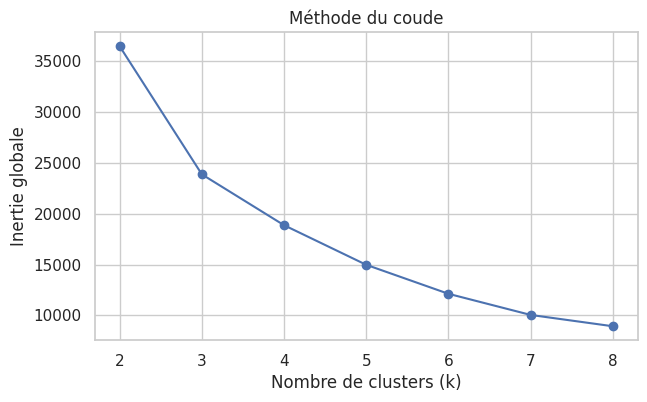

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_kmeans = ["conso_j_median", "conso_j_p95", "ratio_median",
                    "cv", "chute_max", "puissance"]

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df_suffisant[features_kmeans])

inerties, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inerties.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inerties, marker="o")
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Inertie globale")
ax.set_title("Méthode du coude")
plt.show()


In [12]:
K_CHOISI = 5
kmeans_final = KMeans(n_clusters=K_CHOISI, random_state=42, n_init=10)
df_suffisant["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)
centroids = kmeans_final.cluster_centers_

# Score d'anomalie = distance euclidienne au centroïde du cluster assigné
distances = np.sqrt(
    np.sum((X_scaled - centroids[df_suffisant["cluster_kmeans"]]) ** 2, axis=1)
)
df_suffisant["score_kmeans"] = distances

df_suffisant.groupby("cluster_kmeans").agg(
    clients=("id_contrat", "count"),
    conso_j_median=("conso_j_median", "mean"),
    cv=("cv", "mean"),
    chute_max=("chute_max", "mean"),
    puissance=("puissance", "mean"),
).round(2)


,clients,conso_j_median,cv,chute_max,puissance
cluster_kmeans,,,,,
0,9361,15.34,0.25,0.94,4.87
1,58,3473.97,0.30,8.58,45.03
2,25,10.07,1.95,3161.58,6.64
3,280,919.29,0.27,5.41,38.44
4,276,14.78,1.72,514.98,4.94


## 7. Segmentation du portefeuille pour Isolation Forest et LOF

Comme dans le projet original, le portefeuille est regroupé en trois segments
homogènes (résidentiel, professionnel, forte puissance) avant application d'Isolation
Forest et LOF, pour éviter qu'un client industriel ne soit comparé à un client
résidentiel. La pertinence de cette segmentation est validée par un test de
Kruskal-Wallis.

In [13]:
categories_residentiel = ["DOMESTIQUE SOCIAL 1", "DOMESTIQUE SOCIAL 2", "DOMESTIQUE"]
categories_prof = ["GENERAL", "PAIN POPULAIRE", "CHANTIERS"]
categories_fp = ["DEGRESSIF", "ECLAIRAGE PUBLIC", "MT DJIBOUTI",
                 "MT REGION DE INT.", "INDUSTRIEL1", "PETITES & MOYENNES INDUSTRIES"]

df_residentiel = df_suffisant[df_suffisant["nom_categorie"].isin(categories_residentiel)].copy()
df_prof = df_suffisant[df_suffisant["nom_categorie"].isin(categories_prof)].copy()
df_fp = df_suffisant[df_suffisant["nom_categorie"].isin(categories_fp)].copy()

print(f"Résidentiel : {len(df_residentiel)} | Professionnel : {len(df_prof)} | Forte puissance : {len(df_fp)}")


Résidentiel : 7159 | Professionnel : 2320 | Forte puissance : 521


In [14]:
from scipy import stats

stat, p_value = stats.kruskal(
    df_residentiel["conso_j_median"],
    df_prof["conso_j_median"],
    df_fp["conso_j_median"],
)
print(f"Test de Kruskal-Wallis : H = {stat:.2f}, p-value = {p_value:.2e}")


Test de Kruskal-Wallis : H = 5399.01, p-value = 0.00e+00


## 8. Isolation Forest

Le paramètre `contamination` est calibré à partir des taux de suspects IQR
(niveau client) pour chaque segment, comme dans le projet original.

In [15]:
from sklearn.ensemble import IsolationForest

features_iforest = ["conso_j_median", "cv", "chute_max", "conso_j_p95"]

def contamination_iqr(groupe, colonne="ratio_median"):
    q1 = groupe[colonne].quantile(0.25)
    q3 = groupe[colonne].quantile(0.75)
    seuil = q3 + 1.5 * (q3 - q1)
    taux = (groupe[colonne] > seuil).mean()
    return max(min(taux, 0.15), 0.01)  # borné pour rester réaliste

resultats_if = []
for nom, sous_df in [("residentiel", df_residentiel), ("prof", df_prof), ("fp", df_fp)]:
    c = contamination_iqr(sous_df)
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=42)
    scaler = StandardScaler()
    X = scaler.fit_transform(sous_df[features_iforest])
    sous_df["score_iforest_raw"] = -iso.fit(X).score_samples(X)  # + élevé = + anormal
    resultats_if.append(sous_df)

df_final_segmente = pd.concat(resultats_if, ignore_index=True)

# Normalisation min-max par segment
df_final_segmente["score_iforest_norm"] = df_final_segmente.groupby(
    df_final_segmente["nom_categorie"].isin(categories_residentiel)
)["score_iforest_raw"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

print(f"Clients scorés par Isolation Forest : {len(df_final_segmente)}")


Clients scorés par Isolation Forest : 10000


## 9. Local Outlier Factor (LOF)

Le nombre de voisins *k* est sélectionné selon la règle empirique de Breunig et al.
(2000) : k_min = √n, k_max = 2√n, appliquée par segment.

In [16]:
from sklearn.neighbors import LocalOutlierFactor

features_lof = ["conso_j_median", "cv", "chute_max", "conso_j_p95"]

def appliquer_lof(sous_df, k):
    scaler = StandardScaler()
    X = scaler.fit_transform(sous_df[features_lof])
    lof = LocalOutlierFactor(n_neighbors=k)
    lof.fit_predict(X)
    sous_df = sous_df.copy()
    sous_df["score_lof"] = -lof.negative_outlier_factor_
    return sous_df

resultats_lof = []
for nom, sous_df in [("residentiel", df_residentiel), ("prof", df_prof), ("fp", df_fp)]:
    n = len(sous_df)
    k = max(int(np.sqrt(n)), 5)
    scored = appliquer_lof(sous_df, k)
    resultats_lof.append(scored)
    print(f"{nom}: n={n}, k retenu={k}")

df_lof_final = pd.concat(resultats_lof, ignore_index=True)
df_lof_final["score_lof_norm"] = (
    (df_lof_final["score_lof"] - df_lof_final["score_lof"].min())
    / (df_lof_final["score_lof"].max() - df_lof_final["score_lof"].min())
)


residentiel: n=7159, k retenu=84


prof: n=2320, k retenu=48
fp: n=521, k retenu=22


## 10. Score composite et consensus inter-méthodes

Les trois scores normalisés (K-Means, Isolation Forest, LOF) sont moyennés. Un client
est classé comme fortement suspect s'il est détecté par au moins **2 méthodes sur 3**
(seuil : 95e percentile de chaque score).

In [17]:
df_consolide = df_suffisant[["id_contrat", "nom_categorie", "score_kmeans"]].merge(
    df_final_segmente[["id_contrat", "score_iforest_norm"]], on="id_contrat"
).merge(
    df_lof_final[["id_contrat", "score_lof_norm"]], on="id_contrat"
)

# Normalisation min-max du score K-Means
df_consolide["score_kmeans_norm"] = (
    (df_consolide["score_kmeans"] - df_consolide["score_kmeans"].min())
    / (df_consolide["score_kmeans"].max() - df_consolide["score_kmeans"].min())
)

seuil_km = df_consolide["score_kmeans_norm"].quantile(0.95)
seuil_if = df_consolide["score_iforest_norm"].quantile(0.95)
seuil_lof = df_consolide["score_lof_norm"].quantile(0.95)

df_consolide["suspect_km"] = df_consolide["score_kmeans_norm"] > seuil_km
df_consolide["suspect_if"] = df_consolide["score_iforest_norm"] > seuil_if
df_consolide["suspect_lof"] = df_consolide["score_lof_norm"] > seuil_lof

df_consolide["score_composite"] = df_consolide[
    ["score_kmeans_norm", "score_iforest_norm", "score_lof_norm"]
].mean(axis=1)

df_consolide["nb_methodes"] = (
    df_consolide["suspect_km"].astype(int)
    + df_consolide["suspect_if"].astype(int)
    + df_consolide["suspect_lof"].astype(int)
)

print("Répartition par nombre de méthodes ayant détecté le client :")
print(df_consolide["nb_methodes"].value_counts().sort_index())


Répartition par nombre de méthodes ayant détecté le client :
nb_methodes
0    8922
1     767
2     200
3     111
Name: count, dtype: int64


In [18]:
top_suspects = df_consolide[df_consolide["nb_methodes"] >= 2] \
    .sort_values("score_composite", ascending=False)

print(f"Clients suspects (≥2 méthodes) : {len(top_suspects)} sur {len(df_consolide)} "
      f"({100*len(top_suspects)/len(df_consolide):.2f}%)")

top_suspects[["id_contrat", "nom_categorie", "score_kmeans_norm",
              "score_iforest_norm", "score_lof_norm",
              "score_composite", "nb_methodes"]].head(15)


Clients suspects (≥2 méthodes) : 311 sur 10000 (3.11%)


,id_contrat,nom_categorie,score_kmeans_norm,score_iforest_norm,score_lof_norm,score_composite,nb_methodes
5479,105479,INDUSTRIEL1,1.000000,0.828266,0.281180,0.703149,3
3735,103735,ECLAIRAGE PUBLIC,0.112925,0.986137,1.000000,0.699688,3
3316,103316,GENERAL,0.662940,1.000000,0.253242,0.638727,3
3871,103871,DOMESTIQUE SOCIAL 2,0.174893,0.883194,0.843389,0.633826,3
8942,108942,DOMESTIQUE SOCIAL 2,0.633261,0.953400,0.282472,0.623044,3
2179,102179,ECLAIRAGE PUBLIC,0.029289,0.927247,0.823393,0.593310,2
2107,102107,MT DJIBOUTI,0.689356,0.946341,0.094329,0.576676,3
1114,101114,MT DJIBOUTI,0.324892,0.951969,0.401027,0.559296,3
7020,107020,MT DJIBOUTI,0.298426,0.819996,0.401474,0.506632,3
2690,102690,DEGRESSIF,0.188540,0.820906,0.484184,0.497877,3


## 11. Validation contre les labels simulés

⚠️ Dans le projet réel, la validation se fait contre le **registre officiel des
fraudes confirmées par EDD** (812 cas, dont 60 recoupent le jeu modélisé, avec un
enrichissement d'un facteur ≈ 4,8 pour les clients détectés par les 3 méthodes — voir
rapport de stage, section 7.5).

Ici, on valide contre le **statut de fraude simulée** généré artificiellement lors de
la création du jeu de données (variable `fraude_confirmee_simulee`), à titre
illustratif uniquement.

In [19]:
labels = pd.read_csv("labels_simules.csv")
df_valid = df_consolide.merge(labels, on="id_contrat")

taux_base = df_valid["fraude_confirmee_simulee"].mean()
taux_3_methodes = df_valid[df_valid["nb_methodes"] == 3]["fraude_confirmee_simulee"].mean()
taux_2plus = df_valid[df_valid["nb_methodes"] >= 2]["fraude_confirmee_simulee"].mean()

print(f"Taux de fraude simulée dans l'ensemble du portefeuille : {taux_base*100:.2f}%")
print(f"Taux de fraude simulée parmi les clients détectés par ≥2 méthodes : {taux_2plus*100:.2f}%")
print(f"Taux de fraude simulée parmi les clients détectés par les 3 méthodes : {taux_3_methodes*100:.2f}%")
print(f"Facteur d'enrichissement (3 méthodes vs base) : x{taux_3_methodes/taux_base:.1f}")


Taux de fraude simulée dans l'ensemble du portefeuille : 3.27%
Taux de fraude simulée parmi les clients détectés par ≥2 méthodes : 65.92%
Taux de fraude simulée parmi les clients détectés par les 3 méthodes : 84.68%
Facteur d'enrichissement (3 méthodes vs base) : x25.9


## 12. Conclusion

Ce pipeline reproduit fidèlement la méthodologie développée durant le stage chez EDD :

1. Audit et nettoyage rigoureux des données de consommation
2. Construction de 4 variables comportementales discriminantes
3. Détection exploratoire univariée (IQR) puis multivariée (K-Means, Isolation Forest, LOF)
4. Score composite avec critère de consensus inter-méthodes
5. Validation quantitative contre un référentiel de fraude externe

Sur les données réelles du stage (9 853 clients modélisés), cette méthodologie a permis
d'identifier **256 contrats suspects** (dont 102 détectés par les 3 méthodes
simultanément), avec un enrichissement du taux de fraude confirmée d'un facteur
**≈4,8** pour le groupe de consensus le plus strict, par rapport à un contrôle
aléatoire du portefeuille.
